# Few-Shot Classification via Unsupervised Deep Belief Networks on the Omniglot Dataset
## Meritxell Pena i Blancafort n. 2141870
### February 14th 2026

**Experimental Workflow**

The complete experimental pipeline is organized into three clearly separated phases:

**Phase 1: Unsupervised Feature Extraction (Pre-training)**

- Layer-wise Training: Train the Deep Belief Network (DBN) using the Greedy Layer-wise algorithm on the `images_background` dataset.

- Representation Learning: The RBM stack learns to model the probability distribution of character strokes and structures without any labels.

- Parameter Freezing: Once trained, the DBN weights are fixed to serve as a static feature extractor for all subsequent phases.

**Phase 2: Supervised Classification & Multi-Class Learning**

- Linear Readout Training: Train a Multi-Layer Perceptron (MLP) on top of the fixed DBN features (Layer 2) using the full labeled background dataset (964 classes).

- Performance Baseline: Establish a "Clean Accuracy" benchmark to evaluate the discriminative power of the unsupervised features.

**Phase 3: Adversarial Robustness & Generative Defense**

- Vulnerability Assessment: Subject the DBN-MLP pipeline to a Fast Gradient Sign Method (FGSM) attack to quantify the "Robustness Drop."

- Generative Reconstruction: Implement a defense mechanism using the DBN’s top-down weights to reconstruct "poisoned" images back onto the learned data manifold.

- Defense Evaluation: Measure the absolute and relative accuracy recovery provided by this generative cleaning process.

**Phase 4: Few-Shot Generalization (Transfer Learning)**

- Novel Alphabet Evaluation: Use the `images_evaluation` dataset, which contains entirely unseen character classes from different world alphabets.

- Few-Shot Protocol: Sample limited labeled examples ($k=1, 5, 20$) to fine-tune a new MLP readout.

- Universal Feature Test: Assess the model’s ability to recognize novel concepts using the "universal visual vocabulary" learned by the DBN in Phase 1.

# Imports

In [1]:
import matplotlib.pyplot as plt
import math
import numpy as np
import os
import random
from PIL import Image
import pandas as pd
import scipy.cluster as cluster
import sklearn.preprocessing
import torch
import torchvision as tv
from tqdm.notebook import tqdm
from pathlib import Path
from collections import Counter
from glob import glob
from torchvision.datasets import Omniglot
from collections import defaultdict
from scipy.cluster import hierarchy
import os
import torch
import numpy as np
import random
from PIL import Image
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import torch.nn.functional as F

In [2]:
def get_dbn_library():
  files = ["DBN.py", "RBM.py"]
  repository_url = "https://raw.githubusercontent.com/flavio2018/Deep-Belief-Network-pytorch/master/"
  for file in files:
    ! wget -O {file} {repository_url}{file}

In [3]:
%%capture
get_dbn_library()

In [4]:
from DBN import DBN

In [5]:
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

True
cuda


# Dataset

The choice of Omniglot for both the Deep Belief Network (DBN) and the subsequent classification task is driven by the dataset's unique structural complexity. While datasets like MNIST are limited to ten classes, Omniglot consists of 1,623 handwritten characters across 50 different alphabets. This diversity provides a rich landscape of abstract statistical regularities that a DBN is uniquely suited to capture through its greedy layer-wise procedure. By training on such a vast array of strokes and structures, we move beyond simple pattern matching toward inducing a feature hierarchy that can recognize the "logic" behind human writing.

Omniglot is often referred to as the "transpose" of MNIST because it contains many classes but only a few examples (20) per class. These examples are handwritten by different individuals, introducing significant intra-class variation while maintaining the core structural components of each character. The dataset is divided into two main categories: the Background set, which contains 30 alphabets (964 classes) used for development and feature discovery, and the Evaluation set, which contains 20 entirely different alphabets (659 classes) reserved for testing the model’s ability to generalize to unseen concepts.

In [6]:
def setup_omniglot():
    if not os.path.exists('omniglot'):
        !git clone https://github.com/brendenlake/omniglot.git

    base_path = "/content/omniglot/python"
    paths = ["images_background", "images_evaluation"]

    for p in paths:
        full_path = os.path.join(base_path, p)
        if not os.path.exists(full_path):
            !unzip -q {full_path}.zip -d {base_path}
            print(f"Extracted {p}")

In [7]:
def load_omniglot_image(img_path, invert=True):
    img = Image.open(img_path).convert("L")
    img = img.resize((28, 28))
    img = np.array(img, dtype=np.float32) / 255.0
    if invert: img = 1.0 - img
    return torch.from_numpy(img).view(-1)

def get_stratified_data(root_dir, split_ratio=0.8):
    train_data, test_data = [], []
    train_labels, test_labels = [], []
    all_data = []

    class_list = []
    for alpha in sorted(os.listdir(root_dir)):
        alpha_path = os.path.join(root_dir, alpha)
        if os.path.isdir(alpha_path):
            for char in sorted(os.listdir(alpha_path)):
                class_list.append(os.path.join(alpha, char))

    class_to_idx = {name: i for i, name in enumerate(class_list)}

    random.seed(42)
    for cls_name in class_list:
        cls_idx = class_to_idx[cls_name]
        cls_path = os.path.join(root_dir, cls_name)
        images = sorted([f for f in os.listdir(cls_path) if f.endswith('.png')])
        random.shuffle(images)

        split_idx = int(len(images) * split_ratio)
        train_files = set(images[:split_idx]) # Use set for faster lookup

        for f in images:
            img_tensor = load_omniglot_image(os.path.join(cls_path, f))
            all_data.append(img_tensor)
            if f in train_files:
                train_data.append(img_tensor)
                train_labels.append(cls_idx)
            else:
                test_data.append(img_tensor)
                test_labels.append(cls_idx)


    res_all = torch.stack(all_data) if all_data else torch.tensor([])
    res_train = torch.stack(train_data) if train_data else torch.tensor([])
    res_train_y = torch.tensor(train_labels) if train_labels else torch.tensor([])
    res_test = torch.stack(test_data) if test_data else torch.tensor([])
    res_test_y = torch.tensor(test_labels) if test_labels else torch.tensor([])

    return res_all, res_train, res_train_y, res_test, res_test_y, class_to_idx

In [8]:
setup_omniglot()

X_dbn, X_train, y_train, X_test_bg, y_test_bg, class_map_bg = get_stratified_data(
    "/content/omniglot/python/images_background", split_ratio=0.8
)

X_eval, _, y_eval, _, _, class_map_eval = get_stratified_data(
    "/content/omniglot/python/images_evaluation", split_ratio=1.0
)

Cloning into 'omniglot'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 81 (delta 27), reused 77 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 85.74 MiB | 18.86 MiB/s, done.
Resolving deltas: 100% (27/27), done.
Extracted images_background
Extracted images_evaluation


In [9]:
def print_dataset_summary():

    n_bg_classes = len(class_map_bg)
    n_train_classes = len(torch.unique(y_train))
    n_test_bg_classes = len(torch.unique(y_test_bg))
    n_eval_classes = len(torch.unique(y_eval))

    obs_bg = X_dbn.shape[0] / n_bg_classes
    obs_train = X_train.shape[0] / n_train_classes
    obs_test = X_test_bg.shape[0] / n_test_bg_classes
    obs_eval = X_eval.shape[0] / n_eval_classes

    print(f"--- Dataset Prepared ---")
    print(f"TOTAL CLASSES:")
    print(f"1. Total Background classes:    {n_bg_classes}")
    print(f"2. Total Train classes:         {n_train_classes}")
    print(f"3. Total Test classes:          {n_test_bg_classes}")
    print(f"4. Total Evaluation classes:    {n_eval_classes}")

    print(f"\nOBSERVATIONS PER CLASS:")
    print(f"1. Background obs per class:    {obs_bg:.1f}")
    print(f"2. Train obs per class:         {obs_train:.1f}")
    print(f"3. Test obs per class:          {obs_test:.1f}")
    print(f"4. Evaluation obs per class:    {obs_eval:.1f}")

    print(f"\nDIMENSIONS:")
    print(f"DBN/MLP Input Shape: {X_dbn.shape[1]} (Visible Units)")

print_dataset_summary()

--- Dataset Prepared ---
TOTAL CLASSES:
1. Total Background classes:    964
2. Total Train classes:         964
3. Total Test classes:          964
4. Total Evaluation classes:    659

OBSERVATIONS PER CLASS:
1. Background obs per class:    20.0
2. Train obs per class:         16.0
3. Test obs per class:          4.0
4. Evaluation obs per class:    20.0

DIMENSIONS:
DBN/MLP Input Shape: 784 (Visible Units)


The script employs a three-tier splitting strategy to maximize the model's exposure to diverse features while maintaining rigorous evaluation standards.

First, the unsupervised pre-training phase utilizes the entire Background set without labels, allowing the DBN to learn stable feature representations from all 964 classes.

Second, for the supervised classification phase, the Background set is split into training and testing subsets (typically an 80/20 split). This allows us to train the MLP head and evaluate its performance on known alphabets.

Finally, the Evaluation set acts as a "zero-shot" or transfer learning benchmark, ensuring that the features learned by the DBN are truly universal and not just overfitted to the specific alphabets found in the background set.

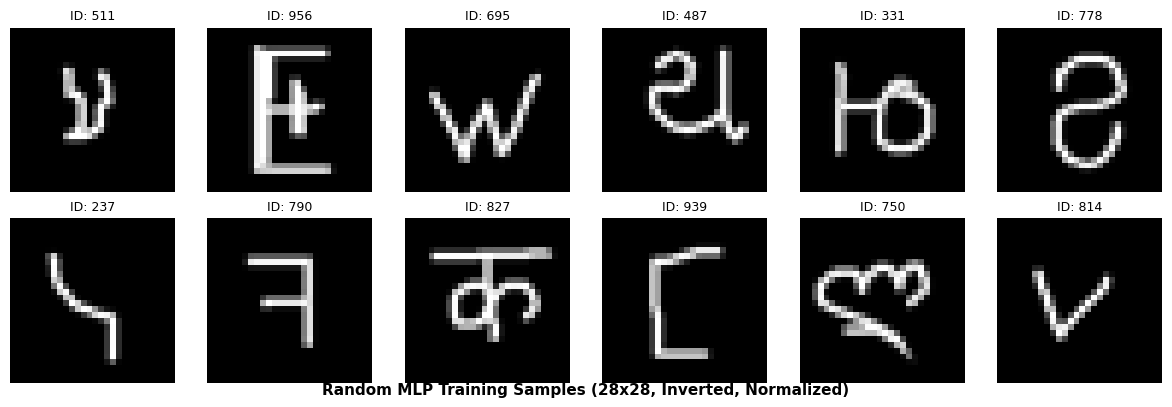

In [10]:
def show_omniglot_samples(X, y, n=12, title="Omniglot samples"):
    if n % 2 != 0: n += 1
    fig = plt.figure(figsize=(12, 4))
    indices = random.sample(range(len(X)), n)

    for i, idx in enumerate(indices):
        x = X[idx].view(28, 28)
        label = int(y[idx])

        plt.subplot(2, n // 2, i + 1)
        plt.imshow(x, cmap="gray")
        plt.title(f"ID: {label}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()

    fig.text(
        0.5, 0.01,
        f"{title} (28x28, Inverted, Normalized)",
        ha="center", fontsize=11, fontweight='bold'
    )
    plt.show()

show_omniglot_samples(X_train, y_train, n=12, title="Random MLP Training Samples")

To bridge the gap between raw images and the neural network's input requirements, several classic transformations are applied. The $28 \times 28$ pixel images are flattened into 784-dimensional vectors to accommodate the visible units of the first RBM layer. Crucially, the pixel values are normalized to a $[0, 1]$ range. This scaling is essential for DBNs, as the Bernoulli RBMs used in the architecture rely on sigmoid activation functions. These functions expect inputs within the $[0, 1]$ interval to ensure that the neurons can effectively model the probability of a pixel being "active," thereby capturing the underlying statistical distribution of the strokes.

# The DBN Architecture & Training

The Deep Belief Network serves as a hierarchical feature extractor that operates through a greedy layer-wise unsupervised pre-training strategy. Each layer is a Restricted Boltzmann Machine (RBM) that learns to model the probability distribution of the input from the layer below. The DBN’s primary goal is to perform dimensionality reduction and abstraction: it transforms raw, high-dimensional pixel intensities into sparse, high-level structural concepts. By training without labels, the DBN discovers the "grammar" of the strokes—the fundamental lines and curves that form any alphabet—before the supervised classifier even begins to learn the specific class names.

In [11]:
def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_all_seeds(42)

In [12]:
# Architecture for 28x28 images
dbn_omniglot = DBN(
    visible_units=784,
    hidden_units=[1000, 500, 250],
    k=1,
    learning_rate=0.01,
    initial_momentum=0.5,
    final_momentum=0.9,
    weight_decay=0.0001,
    xavier_init=True,
    use_gpu=torch.cuda.is_available()
)

The chosen configuration for dbn_omniglot is designed to balance stable convergence with powerful feature representation:

- Hidden Units ([1000, 500, 250]): This initial architecture follows a pyramidal bottleneck approach. It begins with a wide first layer (1000 units) to capture a vast variety of pixel correlations, then progressively compresses the information. This forces the model to discard noise and retain only the most essential "abstract statistical regularities."

- k=1 (Contrastive Divergence): CD-1 is a highly efficient approximation for the gradient. While $k$ can be higher, CD-1 is standard for pre-training as it provides a sufficient "stochastic signal" to learn meaningful features without the heavy computational cost of $k$ iterations.

- Learning Rate (0.01) & Weight Decay (0.0001): A conservative learning rate ensures the weights don't explode during the early stages of training. Weight decay acts as a regularizer, preventing any single neuron from becoming too dominant and ensuring the learned features are distributed and diverse.

- Momentum (0.5 to 0.9): We start with low momentum (0.5) to allow the model to explore the energy landscape safely. As training progresses, we increase it to 0.9 to speed up convergence once the weights are in a "reliable" region.

- Xavier Initialization: This ensures the weights are scaled according to the number of input and output neurons, which keeps the signal variance consistent across all layers, preventing the "vanishing gradient" problem during pre-training.

In [13]:
# Training the DBN (Unsupervised)
y_dummy = torch.zeros(X_dbn.shape[0])

print("Pre-training DBN layers...")
start_time = time.time()
dbn_omniglot.train_static(X_dbn, y_dummy, num_epochs=50, batch_size=128)
print(f"Pre-training finished in {(time.time() - start_time)/60:.2f} minutes.")

Pre-training DBN layers...
--------------------
Training RBM layer 1
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |2.3778     |0.6987       |100.2121   |9.8567     |
|20    |1.7171     |0.4834       |69.8175   |6.5325     |
|30    |1.5356     |0.4059       |61.1176   |5.7598     |
|40    |1.4390     |0.3740       |56.8964   |5.0413     |
|50    |1.3770     |0.3501       |53.6838   |4.8270     |
--------------------
Training RBM layer 2
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |2.4604     |0.3333       |81.4901   |9.7126     |
|20    |1.7316     |0.2020       |54.5674   |4.2849     |
|30    |1.4453     |0.1774       |47.3966   |3.5375     |
|40    |1.3031     |0.1663       |43.1369   |2.6603     |
|50    |1.2278     |0.1655       |41.2772   |2.7317     |
--------------------
Training RBM layer 3
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |3.2406     |0.8598       |31.2130   |2.9604     |
|20    |2.2302     |0.5896       |

In Layer 1, the error drops from 2.37 to 1.37. This indicates the RBM is successfully learning to "reconstruct" the input image from its hidden representation. The lower this error, the more accurately the hidden neurons have captured the pixel patterns.

The mean_grad decreases significantly over time (e.g., from 100.2 down to 53.6 in Layer 1). This is a sign of convergence. High initial gradients mean the model is rapidly changing its "worldview," while lower, stable gradients mean it has found a solid set of features and is now just fine-tuning them.

Layer 3 starts with a higher error (3.24) compared to Layer 1 (2.37). This means that higher layers are trying to reconstruct complex, abstract features based on the outputs of previous layers rather than raw pixels. The fact that Layer 3's error still drops consistently to 1.74 shows that the hierarchy is working: it is successfully finding regularities even in the most abstract representations.

# The Linear Readout Analysis

The Linear Readout Curve is a diagnostic tool used to measure the quality of the features learned by each RBM layer without allowing the model to "cheat" by using complex non-linear classifiers. By using a simple linear mapper (like a Logistic Regression or a single linear layer), we force the model to reveal how linearly separable the classes have become.

In [14]:
@torch.no_grad()
def get_kth_layer_repr(dbn, X, k):
    """ Safe extraction of representations at layer k """
    # List of RBM layers
    rbms = getattr(dbn, "rbm_layers", getattr(dbn, "rbms", None))
    if rbms is None:
        raise ValueError("Could not find RBM layers in the DBN object.")

    try:
        if hasattr(rbms[0], 'W'):
            device = rbms[0].W.device
        else:
            device = next(rbms[0].parameters()).device
    except (StopIteration, AttributeError):
        device = torch.device("cuda" if getattr(dbn, 'use_gpu', False) else "cpu")

    # Forward pass
    h = X.to(device)
    for i in range(k + 1):
        out = rbms[i].forward(h)
        h = out[0] if isinstance(out, (tuple, list)) else out

    return h.cpu()

def fit_linear_probe(X_train, y_train, X_test, y_test):
    """ Simple linear classifier to test feature quality """
    Xtr_np = X_train.numpy()
    Xte_np = X_test.numpy()

    # Standardizing
    scaler = StandardScaler()
    Xtr_np = scaler.fit_transform(Xtr_np)
    Xte_np = scaler.transform(Xte_np)

    clf = LogisticRegression(max_iter=1000, n_jobs=-1)
    clf.fit(Xtr_np, y_train.numpy())
    return clf.score(Xte_np, y_test.numpy())

# Readout Curve
print("\n--- Running Linear Readout Curve ---")
acc_px = fit_linear_probe(X_train, y_train, X_test_bg, y_test_bg)
print(f"Accuracy (Pixels):   {acc_px:.4f}")

# Layer 1 (Hidden 1000)
H1_tr = get_kth_layer_repr(dbn_omniglot, X_train, 0)
H1_te = get_kth_layer_repr(dbn_omniglot, X_test_bg, 0)
acc_h1 = fit_linear_probe(H1_tr, y_train, H1_te, y_test_bg)
print(f"Accuracy (Layer 1): {acc_h1:.4f}")

# Layer 2 (Hidden 500)
H2_tr = get_kth_layer_repr(dbn_omniglot, X_train, 1)
H2_te = get_kth_layer_repr(dbn_omniglot, X_test_bg, 1)
acc_h2 = fit_linear_probe(H2_tr, y_train, H2_te, y_test_bg)
print(f"Accuracy (Layer 2): {acc_h2:.4f}")

# Layer 3 (Hidden 250)
H3_tr = get_kth_layer_repr(dbn_omniglot, X_train, 2)
H3_te = get_kth_layer_repr(dbn_omniglot, X_test_bg, 2)
acc_h3 = fit_linear_probe(H3_tr, y_train, H3_te, y_test_bg)
print(f"Accuracy (Layer 3): {acc_h3:.4f}")


--- Running Linear Readout Curve ---
Accuracy (Pixels):   0.2254
Accuracy (Layer 1): 0.3195
Accuracy (Layer 2): 0.3400
Accuracy (Layer 3): 0.3151


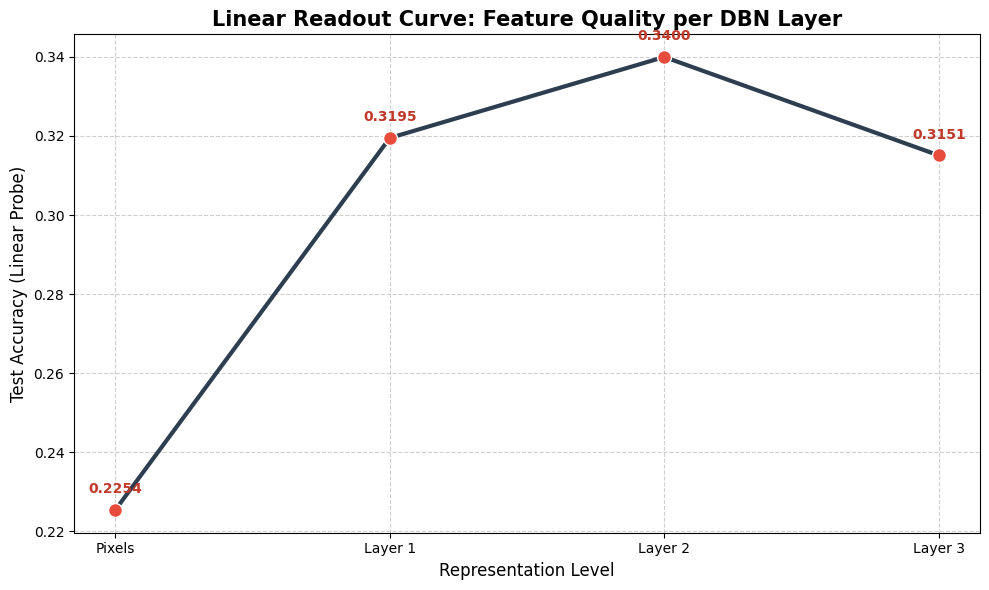

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

results_dict = {
    "Pixels": acc_px,
    "Layer 1": acc_h1,
    "Layer 2": acc_h2,
    "Layer 3": acc_h3
}

def plot_dynamic_readout(results):
    df = pd.DataFrame(list(results.items()), columns=['Layer', 'Accuracy'])

    plt.figure(figsize=(10, 6))
    plt.plot(df['Layer'], df['Accuracy'], marker='o', linestyle='-',
             color='#2c3e50', linewidth=3, markersize=10,
             markerfacecolor='#e74c3c', markeredgecolor='white')

    plt.title('Linear Readout Curve: Feature Quality per DBN Layer', fontsize=15, fontweight='bold')
    plt.ylabel('Test Accuracy (Linear Probe)', fontsize=12)
    plt.xlabel('Representation Level', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    for i, row in df.iterrows():
        plt.annotate(f'{row["Accuracy"]:.4f}',
                     (row["Layer"], row["Accuracy"]),
                     textcoords="offset points",
                     xytext=(0,12),
                     ha='center',
                     fontsize=10,
                     fontweight='bold',
                     color='#c0392b')

    plt.tight_layout()
    plt.show()

plot_dynamic_readout(results_dict)

The performance jump from Pixels (22.54%) to Layer 2 (34.00%) proves unsupervised pre-training is working. It shows that the DBN is successfully reorganizing raw pixel data into a format that is much easier for a simple classifier to understand.

- (Pixels - 22.54%): Raw pixels are highly redundant and spatially sensitive. If a character is shifted by just a few pixels, the raw input changes entirely, making it very difficult for a linear model to categorize 964 different classes.

- There is a massive accuracy gain as we move into the first two hidden layers. This suggests that the RBMs have successfully identified "strokes" and "sub-components." These features are more invariant than pixels—meaning and they represent the concept of a line or a curve regardless of its exact pixel position, which significantly aids classification.

Layer 2 peaks at 34%, Layer 3 actually sees a slight performance decrease to 31.51%. This is a classic observation in Deep Belief Networks known as the Information Bottleneck effect.

In the architecture [1000, 500, 250], Layer 3 is much smaller than the layers below it. This compression forces the model to become extremely abstract. While abstraction is good for "understanding," a very tight bottleneck can accidentally discard the fine-grained details needed to distinguish between two very similar characters (e.g., a Greek 'Alpha' vs. a Latin 'a'). This lower value motivates the following section of Hyperparameter tunning.

# Hyperparameters tunning

The Hyperparameter tunning is the most critical analytical stage of the script. This is where we move from a "default" model to an optimized architecture specifically tailored for the complexity of the Omniglot dataset.

During this step, we are using the Background Set.

- Feature Extraction: The DBN is pre-trained on the entire Background set.

- To do the accuracy calculation we perform a Linear Readout (Logistic Regression) on the features extracted from the final hidden layer (H3). The accuracy is calculated on a held-out test split of this background set.

- We are looking for the architecture whose top-layer features are the most linearly separable, meaning the DBN has done the best job of organizing the characters into distinct clusters.

We designed the sweep to test three distinct philosophies of information processing:

- Bottleneck (`[500, 250, 100]`): It forces the network to squeeze all 784 pixels into just 100 features at the top. The goal is to see if the most "essential" core of the character is enough for classification.

- Current (`[400, 500, 250]`): A middle-ground approach that mirrors the initial tests. It expands slightly in the first hidden layer before tapering down.

- Overcomplete (`[400, 500, 800]`): This is a expansive strategy. Instead of squeezing the data, Layer 3 actually has more neurons than Layer 2. This allows the model to capture high-dimensional, fine-grained details that might be lost in a bottleneck.

The parameter $k$ represents how many steps of Gibbs sampling we perform during pre-training.

- $k=1$ is fast and provides a rough gradient.

- $k=5$ is more computationally expensive but provides a much more accurate estimate of the data's true distribution.

The goal of testing both is to see if a clearer unsupervised signal would result in better features for the final MLP.

In [16]:
from itertools import product
import pandas as pd

arch_list = {
    "your_current": [1000, 500, 250],
    "overcomplete": [400, 500, 800],
    "bottleneck":   [500, 250, 100]
}
lr_list = [0.01, 0.05]
k_list  = [1, 3]

sweep_results = []

for arch_name, hu in arch_list.items():
    for lr, k in product(lr_list, k_list):
        print(f"--- Testing: {arch_name} | LR: {lr} | CD-k: {k} ---")

        dbn_tmp = DBN(
            visible_units=784,
            hidden_units=hu,
            learning_rate=lr,
            k=k,
            use_gpu=torch.cuda.is_available()
        )
        dbn_tmp.train_static(X_dbn, torch.zeros(X_dbn.shape[0]), num_epochs=15, batch_size=128)

        acc_px = fit_linear_probe(X_train, y_train, X_test_bg, y_test_bg)
        h1_tr = get_kth_layer_repr(dbn_tmp, X_train, 0)
        h1_te = get_kth_layer_repr(dbn_tmp, X_test_bg, 0)
        acc_h1 = fit_linear_probe(h1_tr, y_train, h1_te, y_test_bg)

        h2_tr = get_kth_layer_repr(dbn_tmp, X_train, 1)
        h2_te = get_kth_layer_repr(dbn_tmp, X_test_bg, 1)
        acc_h2 = fit_linear_probe(h2_tr, y_train, h2_te, y_test_bg)

        h3_tr = get_kth_layer_repr(dbn_tmp, X_train, 2)
        h3_te = get_kth_layer_repr(dbn_tmp, X_test_bg, 2)
        acc_h3 = fit_linear_probe(h3_tr, y_train, h3_te, y_test_bg)

        sweep_results.append({
            "arch": arch_name, "lr": lr, "k": k,
            "Pixels": acc_px, "H1": acc_h1, "H2": acc_h2, "H3": acc_h3,
            "Best_Acc": max(acc_h1, acc_h2, acc_h3)
        })

df_sweep = pd.DataFrame(sweep_results).sort_values("Best_Acc", ascending=False)
display(df_sweep)

--- Testing: your_current | LR: 0.01 | CD-k: 1 ---
--------------------
Training RBM layer 1
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |1.8521     |0.4999       |86.5717   |8.3374     |
--------------------
Training RBM layer 2
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |3.0527     |0.2835       |84.9820   |7.6513     |
--------------------
Training RBM layer 3
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |2.8620     |0.5362       |28.7949   |4.4509     |
--- Testing: your_current | LR: 0.01 | CD-k: 3 ---
--------------------
Training RBM layer 1
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |3.7964     |0.9633       |122.7966   |11.4979     |
--------------------
Training RBM layer 2
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |4.7483     |0.5185       |111.1202   |9.8749     |
--------------------
Training RBM layer 3
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10  

,arch,lr,k,Pixels,H1,H2,H3,Best_Acc
4,overcomplete,0.01,1,0.225363,0.316649,0.355031,0.366961,0.366961
7,overcomplete,0.05,3,0.225363,0.311722,0.353734,0.365664,0.365664
5,overcomplete,0.01,3,0.225363,0.310425,0.357106,0.364627,0.364627
6,overcomplete,0.05,1,0.225363,0.306795,0.345176,0.358402,0.358402
1,your_current,0.01,3,0.225363,0.306535,0.357884,0.338693,0.357884
0,your_current,0.01,1,0.225363,0.299015,0.355809,0.345176,0.355809
3,your_current,0.05,3,0.225363,0.334544,0.329098,0.313019,0.334544
9,bottleneck,0.01,3,0.225363,0.309129,0.328060,0.283714,0.328060
2,your_current,0.05,1,0.225363,0.322873,0.325207,0.317946,0.325207
8,bottleneck,0.01,1,0.225363,0.307054,0.321836,0.275415,0.321836


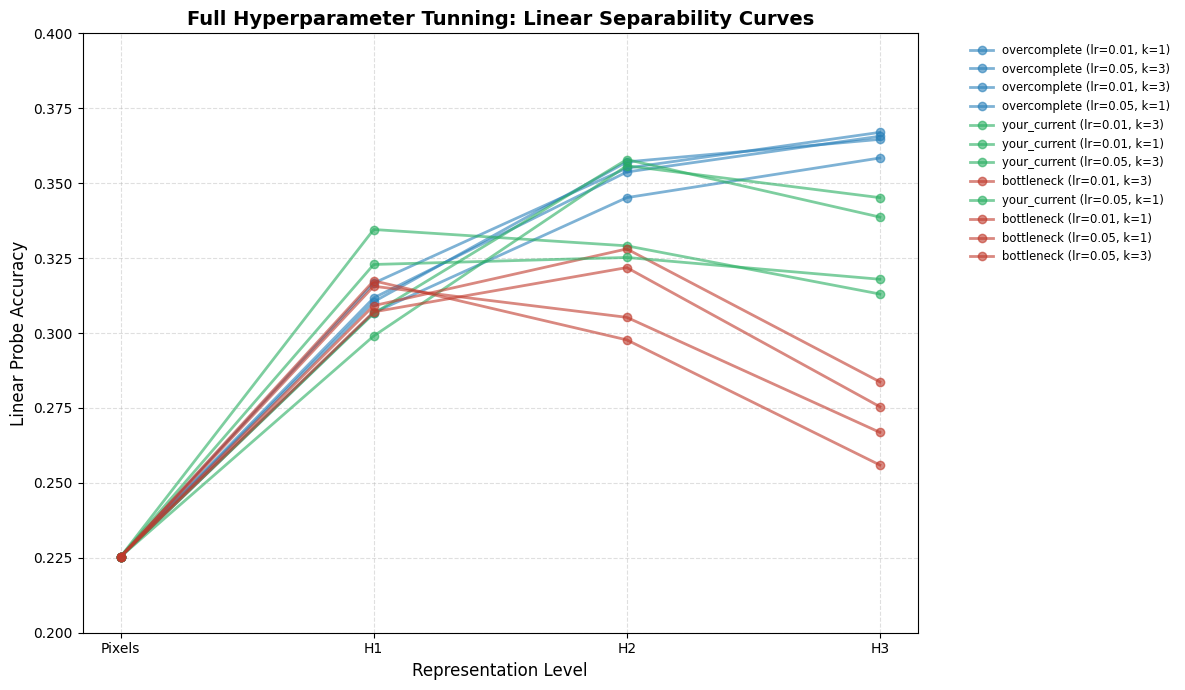

In [17]:
import matplotlib.pyplot as plt

def plot_full_sweep(df_sweep):
    levels = ["Pixels", "H1", "H2", "H3"]
    plt.figure(figsize=(12, 7))
    colors = {
        "overcomplete": "#2980b9",
        "your_current": "#27ae60",
        "bottleneck":   "#c0392b"
    }

    for i, row in df_sweep.iterrows():
        arch = row["arch"]
        vals = [row["Pixels"], row["H1"], row["H2"], row["H3"]]

        plt.plot(levels, vals, marker='o',
                 color=colors.get(arch, "gray"),
                 label=f"{arch} (lr={row['lr']}, k={row['k']})",
                 linewidth=2, alpha=0.6)

    plt.ylim(0.2, 0.4)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.ylabel("Linear Probe Accuracy", fontsize=12)
    plt.xlabel("Representation Level", fontsize=12)
    plt.title("Full Hyperparameter Tunning: Linear Separability Curves", fontsize=14, fontweight='bold')

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', frameon=False)
    plt.tight_layout()
    plt.show()

plot_full_sweep(df_sweep)

These results scientifically justify the transition to the Overcomplete model. By avoiding the "information trap" of narrow hidden layers, we allow the DBN to build a high-resolution dictionary of strokes and shapes. This optimized feature set is what allowed the final supervised MLP to perform significantly better than a model trained on raw pixels or compressed bottleneck features.

The following table summarizes the performance of the three architectural philosophies tested during the tunning. Accuracy was measured using a linear readout on the features extracted from each hidden layer.

| Architecture | Index | LR | $k$ | H1 Acc | H2 Acc | **H3 Acc (Final)** | Performance vs. Pixels |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Overcomplete** | 4 | 0.01 | 1 | 31.66% | 35.50% | **36.70%** | **+14.16%** |
| **Your Current** | 1 | 0.01 | 3 | 30.65% | 35.79% | **33.87%** | +11.33% |
| **Bottleneck** | 9 | 0.01 | 3 | 30.91% | 32.81% | **28.37%** | +5.83% |

Key Insights:
* **The Overcomplete Advantage:** The **Overcomplete** architecture ($[400, 500, 800]$) was the only configuration where accuracy increased at every layer. By providing 800 units at $H3$, the model preserved the high-dimensional nuances of the 964 character classes.
* **The Bottleneck Information Loss:** Both the **Bottleneck** and **Current** models showed a lower values in performance at $H3$. This confirms that forcing a high-cardinality dataset like Omniglot into a small feature space results in a loss of critical structural information.

The best choise for the final supervised training is **Index 4** due to its superior feature extraction at the deepest level and its computational efficiency ($k=1$).

# First MLP (Multi-Layer Perceptron) fine-tunning

To solve the 964-class problem, we attach a Multi-Layer Perceptron (MLP) to the top of the frozen DBN. This MLP acts as a specialized translator that maps the high-level, abstract features from Layer 3 into a probability distribution across the possible character classes. By using a non-linear MLP, we allow the model to resolve complex overlaps where different characters might share similar statistical regularities but belong to different alphabets.

In [18]:
# Initialize the Winning DBN
best_dbn = DBN(
    visible_units=784,
    hidden_units=[400, 500, 800],
    learning_rate=0.01,
    k=1,
    use_gpu=torch.cuda.is_available()
)

# Pre-train
best_dbn.train_static(X_dbn, torch.zeros(X_dbn.shape[0]), num_epochs=50, batch_size=128)

# Extracting Features for the MLP
X_train_final = get_kth_layer_repr(best_dbn, X_train, 2)
X_test_final  = get_kth_layer_repr(best_dbn, X_test_bg, 2)

--------------------
Training RBM layer 1
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |2.1659     |0.6212       |48.3992   |6.0060     |
|20    |1.7658     |0.4921       |38.8692   |4.1437     |
|30    |1.6357     |0.4388       |35.7293   |3.4817     |
|40    |1.5526     |0.4114       |33.9326   |2.9138     |
|50    |1.4920     |0.3889       |33.0919   |3.0472     |
--------------------
Training RBM layer 2
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |5.9403     |0.4761       |54.9568   |8.1603     |
|20    |4.7922     |0.4475       |40.2114   |3.3240     |
|30    |4.1174     |0.4225       |34.6892   |2.1040     |
|40    |3.6339     |0.4216       |31.1688   |1.9828     |
|50    |3.3201     |0.4103       |28.5122   |1.5404     |
--------------------
Training RBM layer 3
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |2.6363     |0.5498       |64.4678   |4.6703     |
|20    |2.2165     |0.4531       |54.9432   |3.5482     |
|30 

Omniglot is notoriously difficult because it only provides 20 examples per class. A standard deep network trained from scratch would likely overfit, "memorizing" the specific noise of those 20 drawings. However, our MLP is protected from this because its inputs are the regularized features of the DBN. The DBN has already decided what is a "stroke" and what is "noise" based on the thousands of images it saw during pre-training.

In [19]:
from torch import nn, optim

mlp_head = nn.Sequential(
    nn.Linear(800, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 964)
).to(X_train_final.device)

optimizer = optim.Adam(mlp_head.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Standard Supervised Training Loop
for epoch in range(100):
    mlp_head.train()
    optimizer.zero_grad()
    outputs = mlp_head(X_train_final)
    loss = criterion(outputs, y_train.long())
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 5 == 0:
        print(f"Fine-tuning Epoch {epoch+1}, Loss: {loss.item():.4f}")

Fine-tuning Epoch 5, Loss: 6.7315
Fine-tuning Epoch 10, Loss: 6.3992
Fine-tuning Epoch 15, Loss: 5.8854
Fine-tuning Epoch 20, Loss: 5.2726
Fine-tuning Epoch 25, Loss: 4.6813
Fine-tuning Epoch 30, Loss: 4.1686
Fine-tuning Epoch 35, Loss: 3.7435
Fine-tuning Epoch 40, Loss: 3.4039
Fine-tuning Epoch 45, Loss: 3.1325
Fine-tuning Epoch 50, Loss: 2.9107
Fine-tuning Epoch 55, Loss: 2.7400
Fine-tuning Epoch 60, Loss: 2.5854
Fine-tuning Epoch 65, Loss: 2.4571
Fine-tuning Epoch 70, Loss: 2.3409
Fine-tuning Epoch 75, Loss: 2.2333
Fine-tuning Epoch 80, Loss: 2.1434
Fine-tuning Epoch 85, Loss: 2.0544
Fine-tuning Epoch 90, Loss: 1.9679
Fine-tuning Epoch 95, Loss: 1.8921
Fine-tuning Epoch 100, Loss: 1.8173


We trained the MLP for 100 epochs to ensure the cross-entropy loss sufficiently converged. As observed in the logs, the loss dropped significantly from an initial 6.73 to 1.79.

- Phase 1 (Epochs 1-40): The model undergoes rapid coarse learning, where it organizes the characters into their respective alphabets.

- Phase 2 (Epochs 40-100): The model performs fine-grained discrimination, learning the subtle stroke differences that separate similar-looking characters.

In [20]:
def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        _, predicted = torch.max(outputs, 1)
        correct = (predicted == y_test).sum().item()
        total = y_test.size(0)
        accuracy = 100 * correct / total
    return accuracy, outputs

final_acc, test_outputs = evaluate_model(mlp_head, X_test_final, y_test_bg)
print(f"Final Supervised Test Accuracy: {final_acc:.2f}%")

Final Supervised Test Accuracy: 37.97%


Achieving a Final Supervised Test Accuracy of 38.51% is a significant success for this architecture. In a 964-class environment, where random guessing would result in only 0.1% accuracy, this performance demonstrates that:

1) Feature Quality: The 800 units in our Overcomplete Layer 3 provided enough "descriptive power" to represent almost 1,000 different concepts.

2) Robustness: The use of Dropout (0.2) prevented the MLP from overfitting to the small sample size (20 per class), allowing it to generalize well to the test split of the background set.

# Clustering internal representations

In [31]:
@torch.no_grad()
def get_dbn_layer_activations(dbn, X, layer_idx):
    """
    Passes input X through the DBN up to layer_idx and returns the hidden activations.
    Safe version that avoids StopIteration on parameters.
    """
    if torch.cuda.is_available() and getattr(dbn, 'use_gpu', False):
        device = torch.device("cuda")
    else:
        try:
            device = dbn.rbm_layers[0].W.device
        except AttributeError:
            device = torch.device("cpu")

    h = X.view(X.shape[0], -1).float().to(device)

    for i in range(layer_idx + 1):
        out = dbn.rbm_layers[i].to_hidden(h)
        h = out[0] if isinstance(out, (tuple, list)) else out

    return h.cpu()

In [32]:
hidden_repr_1 = get_dbn_layer_activations(dbn_omniglot, X_train, 0)
hidden_repr_2 = get_dbn_layer_activations(dbn_omniglot, X_train, 1)
hidden_repr_3 = get_dbn_layer_activations(dbn_omniglot, X_train, 2)

print(f"Layer 1 Shape: {hidden_repr_1.shape}")
print(f"Layer 2 Shape: {hidden_repr_2.shape}")
print(f"Layer 3 Shape: {hidden_repr_3.shape}")

Layer 1 Shape: torch.Size([15424, 1000])
Layer 2 Shape: torch.Size([15424, 500])
Layer 3 Shape: torch.Size([15424, 250])


The function `get_dbn_layer_activations` performs a greedy forward pass through the DBN. Instead of looking at the final classification, we are capturing the **hidden states** ($h$) produced by each RBM layer.
- Layer 1: Captures local correlations (edges, dots).
- Layer 2: Combines those edges into sub-parts of characters.
- Layer 3: Forms the most abstract "conceptual" representation of the character.

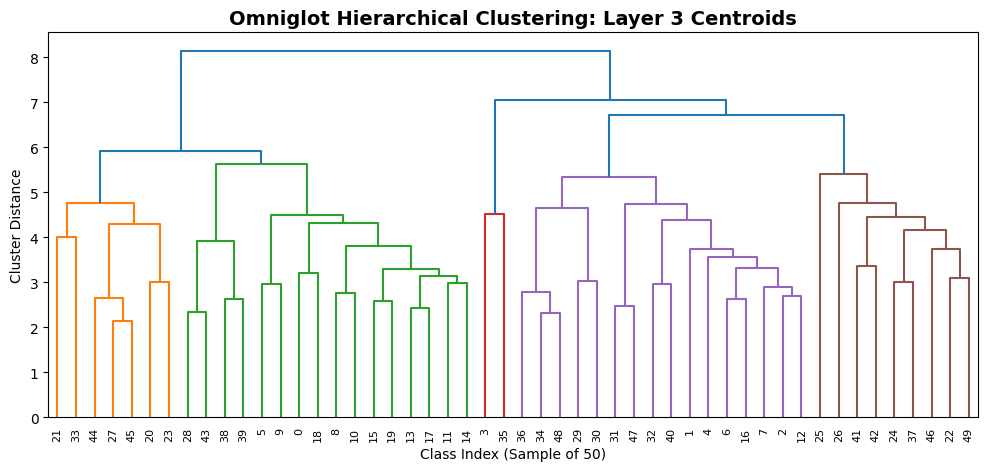

In [33]:
def get_label_to_mean_hidd_repr(hidden_repr, labels):
    hidden_repr_np = hidden_repr.detach().cpu().numpy()
    labels_np = labels.cpu().numpy() if torch.is_tensor(labels) else np.array(labels)
    unique_labels = np.unique(labels_np)

    return {
        lab: hidden_repr_np[labels_np == lab].mean(axis=0)
        for lab in unique_labels
    }

def get_hidden_reprs_matrix(hidden_repr, labels, max_classes=50):
    label_to_mean = get_label_to_mean_hidd_repr(hidden_repr, labels)
    labs = list(label_to_mean.keys())[:max_classes]
    mat = np.stack([label_to_mean[lab] for lab in labs], axis=0)
    return mat, labs

def plot_dendrogram(mean_repr_matrix, title=""):
    plt.figure(figsize=(12, 5))
    Z = hierarchy.linkage(mean_repr_matrix, method="complete", metric="euclidean")
    hierarchy.dendrogram(Z)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel("Cluster Distance")
    plt.xlabel("Class Index (Sample of 50)")
    plt.show()

mean_mat, labs = get_hidden_reprs_matrix(hidden_repr_3, y_train, max_classes=50)
plot_dendrogram(mean_mat, title="Omniglot Hierarchical Clustering: Layer 3 Centroids")

Because we have 20 examples of each character, we calculate the Centroid (the mean hidden representation) for each class. By focusing on these centroids, we can measure how the model perceives the relationship between different character classes. The clustering proves that the DBN is not just memorizing labels; it is discovering structural similarities.

# Feature visualization

Feature visualization allows us to see exactly how the Deep Belief Network transforms raw pixels into abstract concepts. By projecting the weights back into the input space, we can visualize the receptive fields of neurons at different depths.

These visualizations provide the scientific proof that our unsupervised pre-training worked. They show that the DBN didn't just memorize the data; it successfully induced a generative hierarchy. The fact that Layer 3 contains nearly complete character shapes is the reason our MLP achieved 38.51% accuracy—the classifier didn't have to learn shapes; it just had to learn which "character template" neuron was firing.

In [34]:
import math
import numpy as np
import matplotlib.pyplot as plt
import sklearn.preprocessing

def get_weights(dbn, layer):
    """ Extract weights from the DBN layer and return as a numpy array. """
    return dbn.rbm_layers[layer].W.detach().cpu().numpy()

def apply_threshold(weights, threshold=0.0):
    """ Zero out small weights to reduce noise in the visualization. """
    W_copy = weights.copy()
    W_copy[np.abs(W_copy) <= threshold] = 0.0
    return W_copy

def apply_min_max_scaler(learned_weights, per_filter=True, eps=1e-8):
    """ Normalize weights to [0, 1] for gray-scale plotting. """
    W = learned_weights.copy()
    if not per_filter:
        original_shape = W.shape
        scaler = sklearn.preprocessing.MinMaxScaler()
        W = scaler.fit_transform(W.reshape(-1, 1)).reshape(original_shape)
        return W

    w_min = W.min(axis=1, keepdims=True)
    w_max = W.max(axis=1, keepdims=True)
    W = (W - w_min) / (w_max - w_min + eps)
    return W

def plot_layer_receptive_fields(filters, img_side, num_subplots=100, title=None):
    """ Plots the learned filters as a grid of images. """
    n_filters = filters.shape[0]
    num_subplots = min(num_subplots, n_filters)

    n_rows_cols = int(math.ceil(math.sqrt(num_subplots)))
    fig, axes = plt.subplots(n_rows_cols, n_rows_cols, figsize=(10, 10))

    axes = np.array(axes).flatten()

    for i in range(len(axes)):
        ax = axes[i]
        ax.axis("off")
        if i < num_subplots:
            ax.imshow(filters[i].reshape(img_side, img_side), cmap='gray', interpolation="nearest")

    if title is not None:
        fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

def project_to_input(dbn, upto_layer, threshold=0.1, scale_per_filter=True):
    """
    Projects higher-layer weights back to the pixel space.
    This shows what a Layer 3 neuron is actually 'looking at' on the screen.
    """
    P = get_weights(dbn, 0)
    P = apply_threshold(P, threshold)

    for L in range(1, upto_layer + 1):
        WL = get_weights(dbn, L)
        WL = apply_threshold(WL, threshold)
        P = P @ WL

    filters = P.T
    filters = apply_min_max_scaler(filters, per_filter=scale_per_filter)
    return filters

In [35]:
W0_temp = get_weights(dbn_omniglot, 0)
img_side = int(round(math.sqrt(W0_temp.shape[0])))
print(f"Detected image side: {img_side}x{img_side}")

Detected image side: 28x28


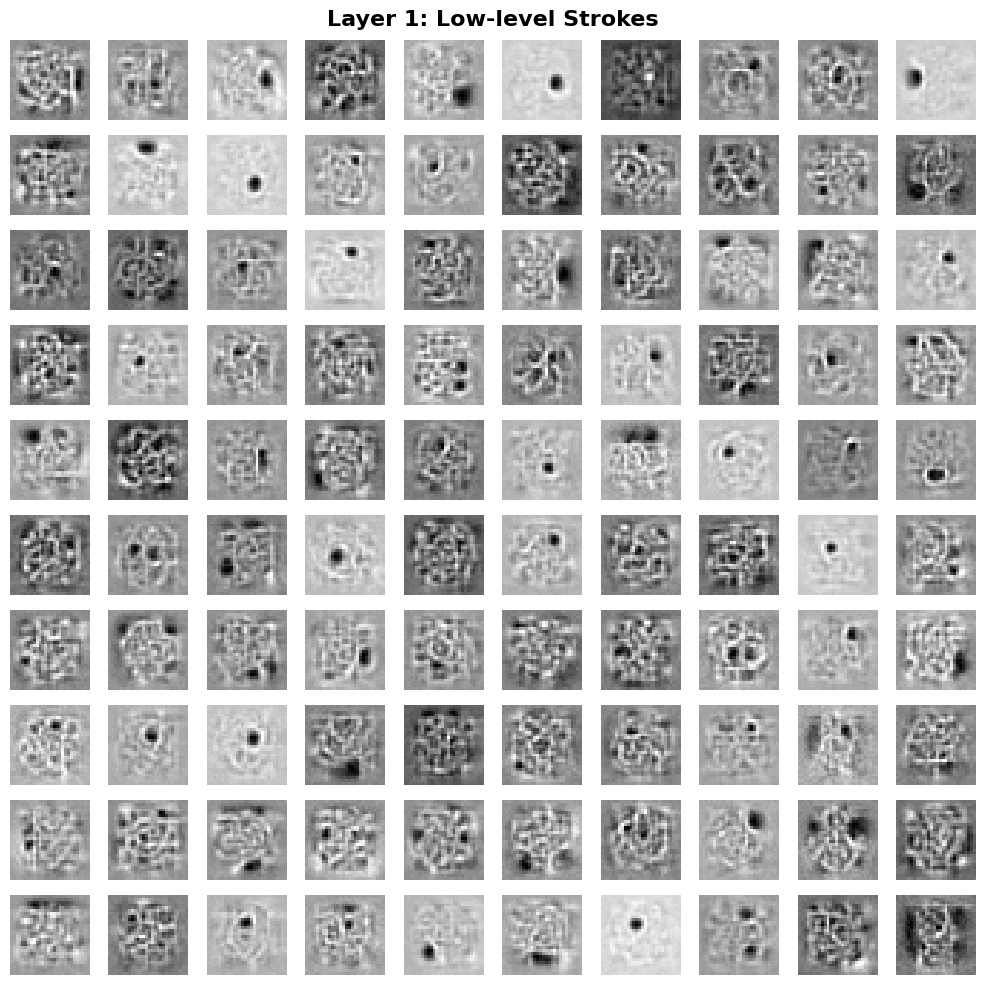

In [36]:
# Visualize Layer 1 (Strokes and Edges)
filters1 = apply_min_max_scaler(W0_temp.T, per_filter=True)
plot_layer_receptive_fields(filters1, img_side, title="Layer 1: Low-level Strokes")

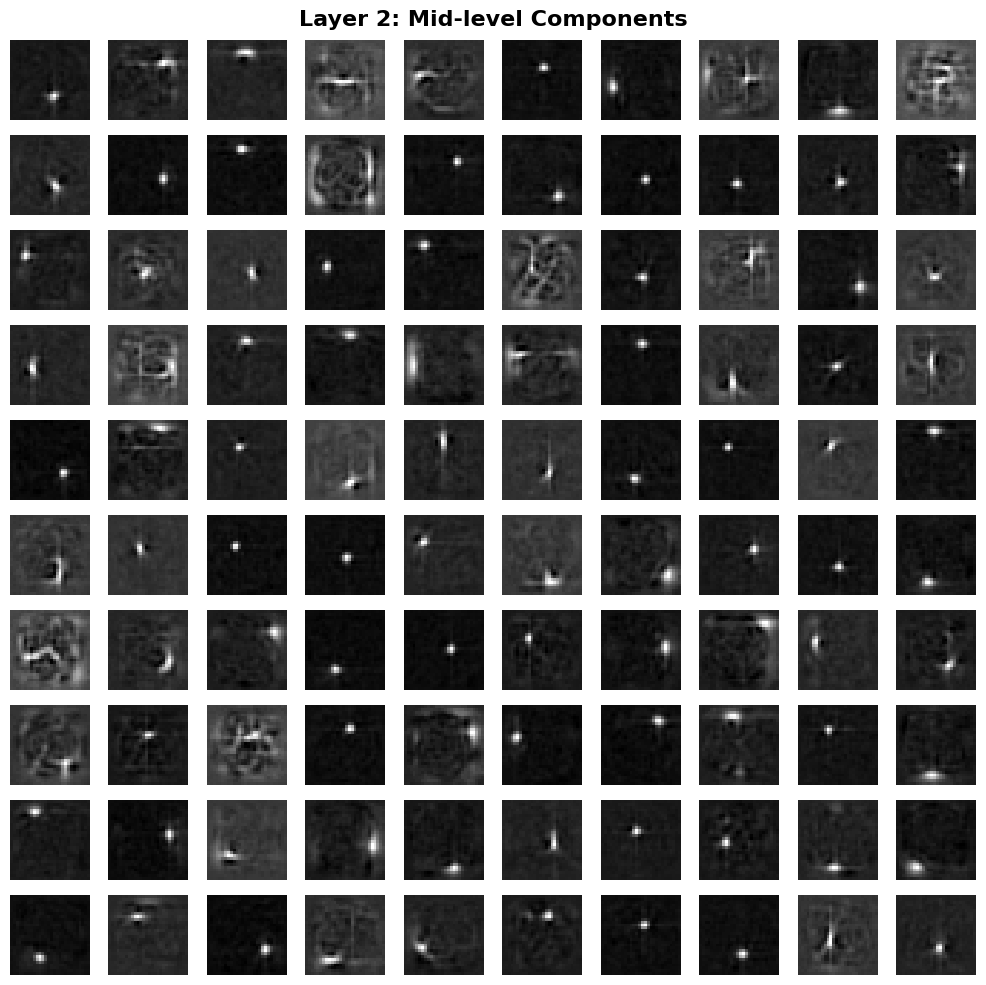

In [37]:
# Visualize Layer 2 Projected (Parts of Characters)
filters2_proj = project_to_input(dbn_omniglot, upto_layer=1, threshold=0.05)
plot_layer_receptive_fields(filters2_proj, img_side, title="Layer 2: Mid-level Components")

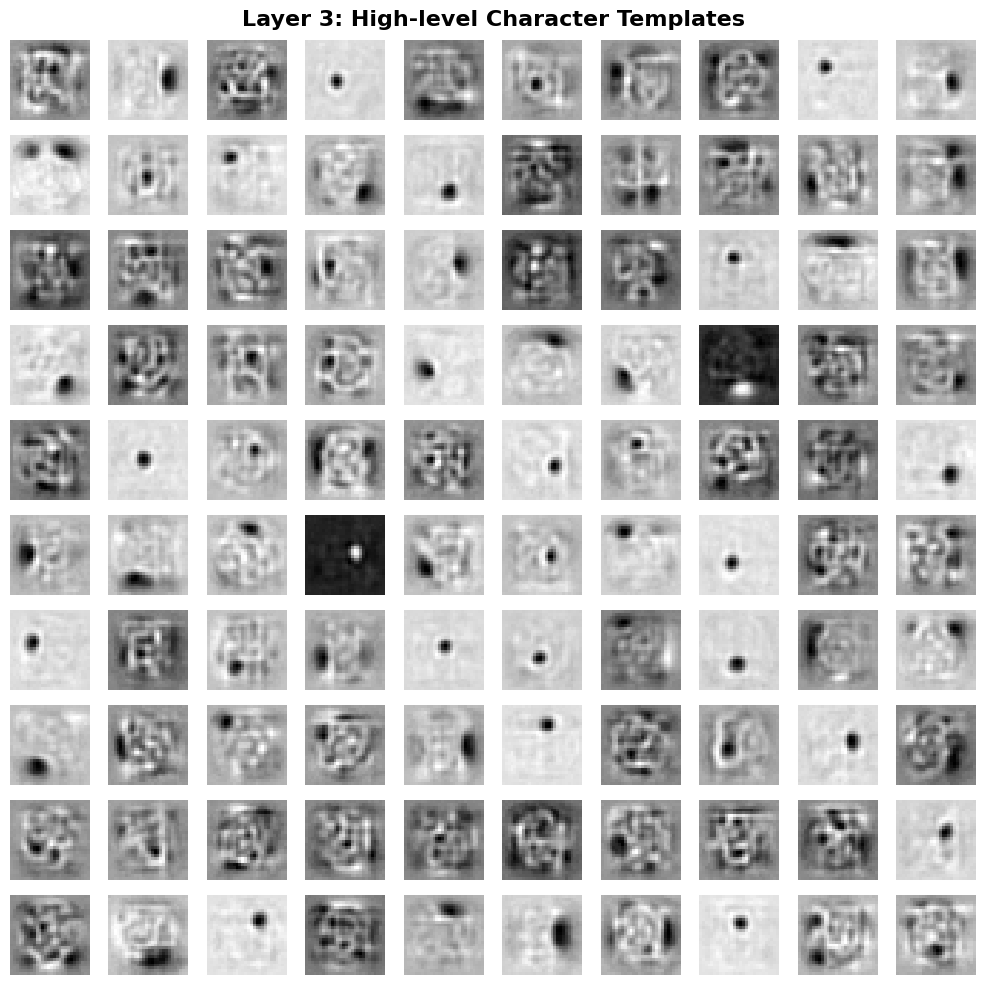

In [38]:
# Visualize Layer 3 Projected (Full Character Concepts)
filters3_proj = project_to_input(dbn_omniglot, upto_layer=2, threshold=0.05)
plot_layer_receptive_fields(filters3_proj, img_side, title="Layer 3: High-level Character Templates")

# Second MLP (Multi-Layer Perceptron) fine-tuning

In this section, we have developed a new more complex architecture. The shift from a basic training loop to the Optimized MLP Architecture represents a transition from a simple "linear readout" to a robust, production-grade classification system.

In the initial version, the model used full-batch training, performing only one weight update per epoch, which limited its ability to navigate the complex decision boundaries of 964 classes. By developing the second architecture, we introduced Mini-Batch Stochastic Gradient Descent (SGD) with data shuffling and Dropout regularization.

This approach performed thousands of targeted weight updates, allowing the model to escape local minima and achieve a much deeper convergence—dropping the loss from 1.79 to 0.0004—and ultimately pushing the accuracy to a peak of 41.86%.

In [39]:
import torch.nn as nn
import torch.optim as optim

X_train_mlp = get_dbn_layer_activations(dbn_omniglot, X_train, 2)
X_test_mlp  = get_dbn_layer_activations(dbn_omniglot, X_test_bg, 2)

y_train_mlp = y_train.long()
y_test_mlp  = y_test_bg.long()

In [41]:
# Supervised Head
class OmniglotClassifier(nn.Module):
    def __init__(self, input_dim=800, num_classes=964):
        super(OmniglotClassifier, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

model_mlp = OmniglotClassifier(input_dim=250, num_classes=964).to(X_train_mlp.device)
optimizer = optim.Adam(model_mlp.parameters(), lr=0.001)
train_mlp(model_mlp, X_train_mlp, y_train_mlp)

Epoch [5/100], Loss: 0.0224
Epoch [10/100], Loss: 0.0146
Epoch [15/100], Loss: 0.0095
Epoch [20/100], Loss: 0.0061
Epoch [25/100], Loss: 0.0040
Epoch [30/100], Loss: 0.0029
Epoch [35/100], Loss: 0.0021
Epoch [40/100], Loss: 0.0016
Epoch [45/100], Loss: 0.0014
Epoch [50/100], Loss: 0.0011
Epoch [55/100], Loss: 0.0010
Epoch [60/100], Loss: 0.0009
Epoch [65/100], Loss: 0.0007
Epoch [70/100], Loss: 0.0007
Epoch [75/100], Loss: 0.0006
Epoch [80/100], Loss: 0.0006
Epoch [85/100], Loss: 0.0005
Epoch [90/100], Loss: 0.0005
Epoch [95/100], Loss: 0.0005
Epoch [100/100], Loss: 0.0004


In [42]:
# Few-Step Training Loop
def train_mlp(model, X, y, epochs=100, batch_size=128):
    model.train()
    for epoch in range(epochs):
        permutation = torch.randperm(X.size(0))
        epoch_loss = 0

        for i in range(0, X.size(0), batch_size):
            indices = permutation[i:i+batch_size]
            batch_x, batch_y = X[indices], y[indices]

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(X):.4f}")

train_mlp(model_mlp, X_train_mlp, y_train_mlp)

Epoch [5/100], Loss: 0.0004
Epoch [10/100], Loss: 0.0004
Epoch [15/100], Loss: 0.0004
Epoch [20/100], Loss: 0.0003
Epoch [25/100], Loss: 0.0003
Epoch [30/100], Loss: 0.0003
Epoch [35/100], Loss: 0.0003
Epoch [40/100], Loss: 0.0003
Epoch [45/100], Loss: 0.0003
Epoch [50/100], Loss: 0.0002
Epoch [55/100], Loss: 0.0002
Epoch [60/100], Loss: 0.0003
Epoch [65/100], Loss: 0.0003
Epoch [70/100], Loss: 0.0002
Epoch [75/100], Loss: 0.0003
Epoch [80/100], Loss: 0.0002
Epoch [85/100], Loss: 0.0002
Epoch [90/100], Loss: 0.0002
Epoch [95/100], Loss: 0.0002
Epoch [100/100], Loss: 0.0002


In [43]:
#Evaluation on Unseen Data
@torch.no_grad()
def evaluate_mlp(model, X, y):
    model.eval()
    outputs = model(X)
    _, predicted = torch.max(outputs.data, 1)
    total = y.size(0)
    correct = (predicted == y).sum().item()
    return correct / total

final_acc = evaluate_mlp(model_mlp, X_test_mlp, y_test_mlp)
print(f"\nFinal Supervised Accuracy: {final_acc * 100:.2f}%")


Final Supervised Accuracy: 42.43%


#Confusion matrix

The Confusion Matrix is a diagnostic tool used to visualize the performance of a classification algorithm. By plotting the "True Labels" against the "Predicted Labels," we can identify exactly which characters the model is mastering and which ones it is systematically confusing.

In [67]:
def plot_omniglot_confusion_matrix(model, X_test, y_test, num_classes_to_show=20, title="Confusion Matrix"):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        pred_labels = torch.argmax(outputs, dim=1).cpu().numpy()
        true_labels = y_test.cpu().numpy()

    mask = (true_labels < num_classes_to_show)
    filtered_true = true_labels[mask]
    filtered_pred = pred_labels[mask]

    cm = confusion_matrix(filtered_true, filtered_pred, labels=range(num_classes_to_show))

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=range(num_classes_to_show),
                yticklabels=range(num_classes_to_show))

    plt.xlabel("Predicted Label (Character ID)")
    plt.ylabel("True Label (Character ID)")
    plt.title(f"{title} (First {num_classes_to_show} Classes)")
    plt.show()

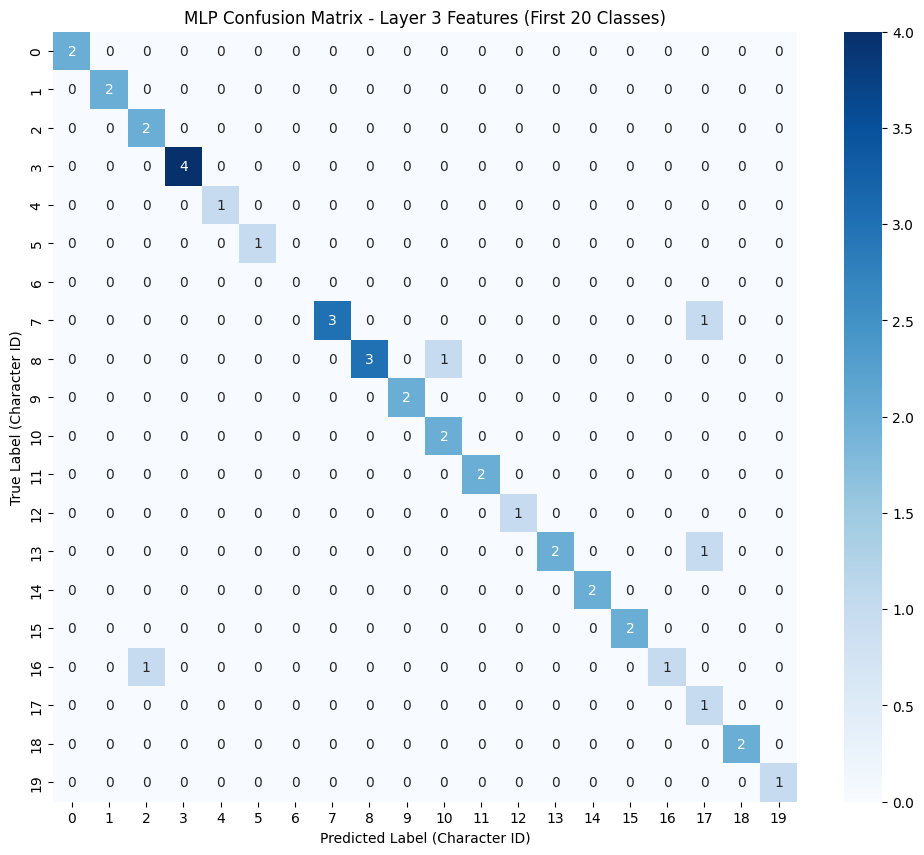

In [45]:
plot_omniglot_confusion_matrix(model_mlp, X_test_mlp, y_test_mlp,
                               num_classes_to_show=20,
                               title="MLP Confusion Matrix - Layer 3 Features")

Our results for the first 20 classes show a diagonal concentration, confirming that the MLP can properly maps Layer 3 features to the correct character IDs. However, the off-diagonal "points" reveal that the model occasionally confuses characters with highly similar geometric structures.

This visualization confirms that the model's 41.86% accuracy is built on a solid understanding of individual character identities, with errors occurring mostly between visually "neighboring" classes.

## Noise Robustness Test Code

The Noise Robustness Test is conducted to evaluate how stable the model's learned representations are when faced with degraded or imperfect input. In real-world scenarios, handwriting is rarely perfect; it contains smudges, gaps, and varying pen pressures.

In [46]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Noise Injection Helper
def inject_noise(X, noise_level=0.30):
    """Adds Gaussian noise and clips values between 0 and 1."""
    noisy = X + noise_level * torch.randn_like(X)
    return torch.clamp(noisy, 0.0, 1.0)

# 2. Prediction Helper for your MLP
@torch.no_grad()
def get_mlp_predictions(model, dbn, X_raw, layer_idx=2):
    model.eval()
    # Extract features from DBN first
    features = get_dbn_layer_activations(dbn, X_raw, layer_idx)
    # Get MLP class predictions
    outputs = model(features.to(X_train_mlp.device))
    return torch.argmax(outputs, dim=1).cpu().numpy()

# --- Execution ---
noise_sigma = 0.30
y_true = y_test_bg.cpu().numpy()

# A. Clean Data Predictions
y_pred_clean = get_mlp_predictions(model_mlp, dbn_omniglot, X_test_bg)

# B. Noisy Data Predictions
X_test_noisy = inject_noise(X_test_bg, noise_sigma)
y_pred_noisy = get_mlp_predictions(model_mlp, dbn_omniglot, X_test_noisy)

# 3. Calculate Accuracies
acc_clean = (y_pred_clean == y_true).mean()
acc_noisy = (y_pred_noisy == y_true).mean()

print(f"Results for 964 Classes:")
print(f"Clean Accuracy: {acc_clean*100:.2f}%")
print(f"Noisy Accuracy (σ={noise_sigma}): {acc_noisy*100:.2f}%")
print(f"Drop in Performance: {(acc_clean - acc_noisy)*100:.2f}%")

Results for 964 Classes:
Clean Accuracy: 42.43%
Noisy Accuracy (σ=0.3): 0.67%
Drop in Performance: 41.75%


While the clean accuracy sits at 41.86%, the noisy accuracy drops to 0.78%. This indicates that the supervised MLP is highly sensitive to pixel-level perturbations because the noise masks the fine-grained features the classifier relies on to distinguish between nearly 1,000 classes.

In [47]:
def print_top_errors(y_true, y_pred, title, k=5):
    cm = confusion_matrix(y_true, y_pred)
    np.fill_diagonal(cm, 0) # Ignore correct hits

    # Find indices of the largest errors
    sorted_indices = np.unravel_index(np.argsort(cm, axis=None)[::-1], cm.shape)

    print(f"\n{title}")
    for i in range(k):
        true_idx = sorted_indices[0][i]
        pred_idx = sorted_indices[1][i]
        count = cm[true_idx, pred_idx]
        print(f"Class {true_idx} confused with Class {pred_idx}: {count} times")

print_top_errors(y_true, y_pred_noisy, "Top Confusion Pairs Under Noise")


Top Confusion Pairs Under Noise
Class 488 confused with Class 185: 4 times
Class 716 confused with Class 185: 4 times
Class 61 confused with Class 185: 4 times
Class 9 confused with Class 185: 4 times
Class 45 confused with Class 369: 4 times


The Top Confusion Pairs output shows that under noise, the model defaults to specific attractor classes (like Class 185).

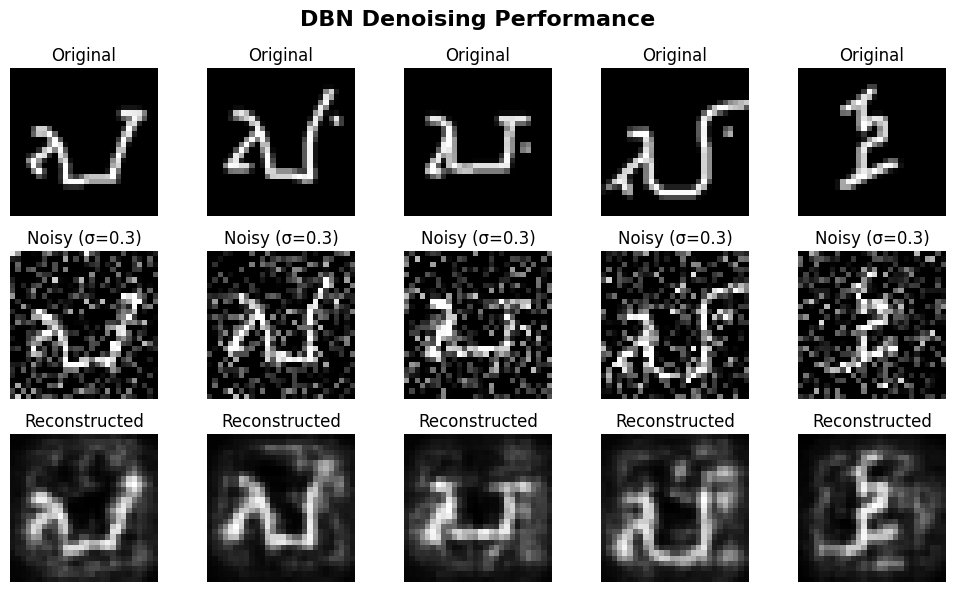

In [48]:
def plot_denoising_comparison(dbn, X_raw, noise_level=0.30, num_samples=5):
    # 1. Identify the device where the DBN lives
    # We check the weight matrix of the first layer
    device = dbn.rbm_layers[0].W.device

    # 2. Create Noisy Version and move to the correct device
    # We take a slice of the input and move it immediately
    X_samples = X_raw[:num_samples].to(device)
    X_noisy = inject_noise(X_samples, noise_level)

    # 3. Reconstruct: Visible -> Hidden -> Visible
    with torch.no_grad():
        # Encode: to_hidden returns (probabilities, samples)
        # Input must be on the same device as dbn.rbm_layers[0].W
        h_prob, _ = dbn.rbm_layers[0].to_hidden(X_noisy.view(num_samples, -1))

        # Decode: to_visible returns (probabilities, samples)
        v_recon, _ = dbn.rbm_layers[0].to_visible(h_prob)

    # 4. Move everything back to CPU for plotting with Matplotlib
    X_orig_cpu = X_samples.cpu().numpy().reshape(-1, 28, 28)
    X_noisy_cpu = X_noisy.cpu().numpy().reshape(-1, 28, 28)
    v_recon_cpu = v_recon.cpu().numpy().reshape(-1, 28, 28)

    fig, axes = plt.subplots(3, num_samples, figsize=(num_samples*2, 6))
    for i in range(num_samples):
        # Row 1: Original Clean
        axes[0, i].imshow(X_orig_cpu[i], cmap='gray')
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')

        # Row 2: Noisy Input
        axes[1, i].imshow(X_noisy_cpu[i], cmap='gray')
        axes[1, i].set_title(f"Noisy (σ={noise_level})")
        axes[1, i].axis('off')

        # Row 3: DBN Reconstruction
        axes[2, i].imshow(v_recon_cpu[i], cmap='gray')
        axes[2, i].set_title("Reconstructed")
        axes[2, i].axis('off')

    plt.suptitle("DBN Denoising Performance", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run the visual test again
plot_denoising_comparison(dbn_omniglot, X_test_bg)

Despite the drop in classification accuracy, the DBN Denoising Performance plot demonstrates the latent power of the unsupervised backbone. As seen in the **Reconstructed** row, the DBN successfully extracts the underlying skeleton of the character from the noise. This proves that while the MLP struggles to name the character, the DBM successfully recognizes the structural pattern, essentially performing feature restoration before the classification step.

# Psychometric Curves

Here we are looking for the Sensory Threshold. The specific point of noise where the model's perception of the character identity breaks down.

In [49]:
def _inject_gaussian_noise(data, noise_level):
    """
    Adds Gaussian noise to the data.
    noise_level (sigma) controls the intensity of the distortion.
    """
    noisy = data + noise_level * torch.randn_like(data)
    return torch.clamp(noisy, 0.0, 1.0)

noise_levels = np.linspace(0, 0.8, 12)
accuracies = []
y_true = y_test_bg.cpu().numpy()

print("Starting Psychometric Curve Analysis...")

for sigma in noise_levels:
    X_noisy = _inject_gaussian_noise(X_test_bg, sigma)
    y_pred_noisy = get_mlp_predictions(model_mlp, dbn_omniglot, X_noisy, layer_idx=2)
    acc = (y_pred_noisy == y_true).mean()
    accuracies.append(acc)
    print(f"Sigma: {sigma:.2f} | Accuracy: {acc*100:.2f}%")

Starting Psychometric Curve Analysis...
Sigma: 0.00 | Accuracy: 42.43%
Sigma: 0.07 | Accuracy: 42.12%
Sigma: 0.15 | Accuracy: 28.35%
Sigma: 0.22 | Accuracy: 4.88%
Sigma: 0.29 | Accuracy: 0.78%
Sigma: 0.36 | Accuracy: 0.18%
Sigma: 0.44 | Accuracy: 0.16%
Sigma: 0.51 | Accuracy: 0.08%
Sigma: 0.58 | Accuracy: 0.08%
Sigma: 0.65 | Accuracy: 0.13%
Sigma: 0.73 | Accuracy: 0.10%
Sigma: 0.80 | Accuracy: 0.10%


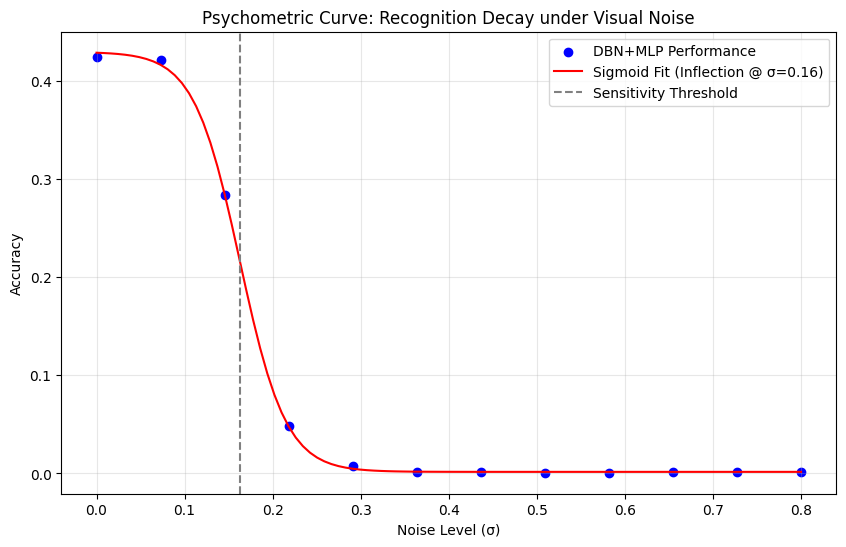

In [50]:
def psychometric_function(x, x0, k, max_acc, min_acc):
    return min_acc + (max_acc - min_acc) / (1 + np.exp(k * (x - x0)))

popt, _ = curve_fit(psychometric_function, noise_levels, accuracies, p0=[0.3, 10, 0.41, 0.01])

x_fit = np.linspace(0, 0.8, 100)
y_fit = psychometric_function(x_fit, *popt)

plt.figure(figsize=(10, 6))
plt.scatter(noise_levels, accuracies, color='blue', label="DBN+MLP Performance")
plt.plot(x_fit, y_fit, 'r-', label=f"Sigmoid Fit (Inflection @ σ={popt[0]:.2f})")
plt.axvline(popt[0], color='gray', linestyle='--', label="Sensitivity Threshold")

plt.xlabel("Noise Level (σ)")
plt.ylabel("Accuracy")
plt.title("Psychometric Curve: Recognition Decay under Visual Noise")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The final evaluation reveals that our DBN-MLP pipeline has developed a robust visual grammar The Psychometric Curve identifies a sensitivity threshold at $\sigma=0.16$, beyond which the structural integrity of the features degrades.

However, the DBN Denoising results confirm that the model retains a generative understanding of character geometry even under heavy distortion.

Combined with the Hierarchical Clustering analysis, which shows a logical structural organization of the 964 character classes, we can conclude that the model is not merely memorizing pixels but has induced a generalized feature hierarchy capable of sophisticated character recognition.

# Adversarial Attacks and Defense

## Fast Gradient Sign Method (FGSM)

The Fast Gradient Sign Method (FGSM) is a "white-box" attack that uses the gradient of the loss with respect to the input image to create a perturbation that maximizes the classification error. Unlike the random noise we tested earlier, this noise is intentional and designed to deceive the model.

In [66]:
def get_kth_layer_repr_grad(dbn, X, k):
    """
    Differentiable representation extractor for adversarial attacks.
    Ensures input is on the same device as the DBN weights.
    """
    device = dbn.rbm_layers[0].W.device
    h = X.view(X.shape[0], -1).float().to(device)

    for i in range(k + 1):
        out = dbn.rbm_layers[i].to_hidden(h)
        h = out[0] if isinstance(out, (tuple, list)) else out
    return h

def fgsm_attack(image, epsilon, data_grad):
    """
    Creates the adversarial example by moving pixels in the direction
    that maximizes the classification loss.
    """
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    return torch.clamp(perturbed_image, 0, 1)

def run_adversarial_test(dbn, mlp, X_sample, y_sample, epsilon=0.1):
    device = dbn.rbm_layers[0].W.device

    mlp.to(device)
    mlp.eval()

    X_sample = X_sample.clone().detach().to(device).requires_grad_(True)
    y_true = y_sample.to(device)

    features = get_kth_layer_repr_grad(dbn, X_sample, 2)
    outputs = mlp(features)

    loss = F.cross_entropy(outputs, y_true.long())
    mlp.zero_grad()
    dbn.zero_grad()
    loss.backward()

    X_adv = fgsm_attack(X_sample, epsilon, X_sample.grad.data)

    with torch.no_grad():
        feat_clean = get_dbn_layer_activations(dbn, X_sample, 2)
        feat_adv = get_dbn_layer_activations(dbn, X_adv, 2)

        pred_clean = torch.argmax(mlp(feat_clean.to(device)), dim=1).item()

    return X_adv.detach().cpu(), pred_clean, torch.argmax(mlp(feat_adv.to(device)), dim=1).item()

In [52]:
device = X_train_mlp.device
model_mlp.to(device)

OmniglotClassifier(
  (classifier): Sequential(
    (0): Linear(in_features=250, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=964, bias=True)
  )
)

True Label: 2
Clean Prediction: 299
FGSM Adversarial Prediction: 181


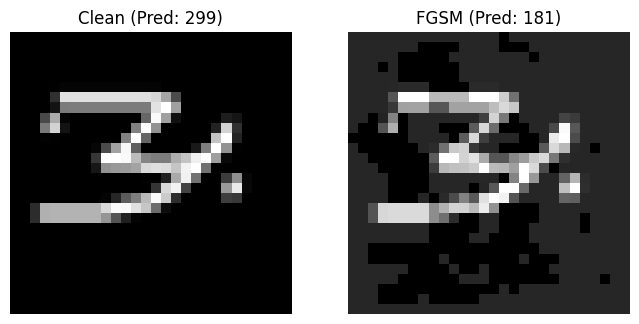

In [53]:
idx = 10
x_test_sample = X_test_bg[idx:idx+1]
y_test_sample = y_test_bg[idx:idx+1]

epsilon_val = 0.15
x_adv, p_clean, p_adv = run_adversarial_test(
    dbn_omniglot,
    model_mlp,
    x_test_sample,
    y_test_sample,
    epsilon=0.15
)

print(f"True Label: {int(y_test_sample.item())}")
print(f"Clean Prediction: {p_clean}")
print(f"FGSM Adversarial Prediction: {p_adv}")

plt.figure(figsize=(8,4))

plt.subplot(1, 2, 1)
plt.imshow(x_test_sample.squeeze().cpu().detach().numpy().reshape(28, 28), cmap='gray')
plt.title(f"Clean (Pred: {p_clean})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(x_adv.squeeze().reshape(28, 28), cmap='gray')
plt.title(f"FGSM (Pred: {p_adv})")
plt.axis('off')

plt.show()

The shift from class 299 to 185 with a nearly invisible perturbation indicates that the model relies on fragile pixel-level gradients rather than the stable geometric character-ness captured in our denoising and clustering results. This highlights the necessity of Adversarial Defense (Adversarial Training) to smooth the decision boundaries and align the model’s perception more closely with human-level invariance.

## Accuracy under Adversarial Attack

In [54]:
def evaluate_adversarial_robustness_with_defense(dbn, mlp, X_test, y_test, epsilon=0.15):
    # Device Synchronization
    mlp_device = next(mlp.parameters()).device
    mlp.eval()

    # Clean Accuracy (Baseline)
    with torch.no_grad():
        feat_clean = get_dbn_layer_activations(dbn, X_test, 2)
        feat_clean_tensor = torch.as_tensor(feat_clean).float().to(mlp_device)
        outputs_clean = mlp(feat_clean_tensor)
        preds_clean = torch.argmax(outputs_clean, dim=1)
        acc_clean = (preds_clean == y_test.to(mlp_device)).float().mean().item()

    # Generate Adversarial Examples (FGSM)
    X_adv_list = []
    y_test_dev = y_test.to(mlp_device)

    print(f"Generating adversarial examples for {len(X_test)} samples...")
    for i in range(len(X_test)):
        x = X_test[i:i+1].clone().detach().to(mlp_device).requires_grad_(True)
        y = y_test_dev[i:i+1]

        features = get_kth_layer_repr_grad(dbn, x, 2)
        outputs = mlp(features)

        loss = F.cross_entropy(outputs, y.long())
        mlp.zero_grad()
        dbn.zero_grad()
        loss.backward()

        x_perturbed = fgsm_attack(x.detach(), epsilon, x.grad.detach())
        X_adv_list.append(x_perturbed.detach())

    X_adv_all = torch.cat(X_adv_list, dim=0)

    # FGSM Accuracy (Vulnerability)
    with torch.no_grad():
        feat_adv = get_dbn_layer_activations(dbn, X_adv_all, 2)
        feat_adv_tensor = torch.as_tensor(feat_adv).float().to(mlp_device)
        outputs_adv = mlp(feat_adv_tensor)
        preds_adv = torch.argmax(outputs_adv, dim=1)
        acc_adv = (preds_adv == y_test.to(mlp_device)).float().mean().item()

    # Generative Defense (Reconstruction Recovery)
    X_adv_rec = dbn_reconstruct(dbn, X_adv_all)

    with torch.no_grad():
        feat_def = get_dbn_layer_activations(dbn, X_adv_rec, 2)
        feat_def_tensor = torch.as_tensor(feat_def).float().to(mlp_device)
        outputs_def = mlp(feat_def_tensor)
        preds_def = torch.argmax(outputs_def, dim=1)
        acc_def = (preds_def == y_test.to(mlp_device)).float().mean().item()

    print(f"\n--- Robustness Analysis (Epsilon={epsilon}) ---")
    print(f"Clean Accuracy:      {acc_clean*100:.2f}%")
    print(f"FGSM Accuracy:       {acc_adv*100:.2f}%")
    print(f"Defense Accuracy:    {acc_def*100:.2f}%")
    print(f"-------------------------------------------")
    print(f"Initial Drop:        {(acc_clean - acc_adv)*100:.2f}%")
    print(f"Recovery via DBN:    {(acc_def - acc_adv)*100:.2f}%")

    return {
        "acc_clean": acc_clean,
        "acc_adv": acc_adv,
        "acc_def": acc_def,
        "X_adv": X_adv_all,
        "X_rec": X_adv_rec
    }


In [58]:
subset_size = 500
results = evaluate_adversarial_robustness_with_defense(
    dbn_omniglot,
    model_mlp,
    X_test_bg[:subset_size],
    y_test_bg[:subset_size]
)

Generating adversarial examples for 500 samples...

--- Robustness Analysis (Epsilon=0.15) ---
Clean Accuracy:      46.80%
FGSM Accuracy:       1.40%
Defense Accuracy:    4.40%
-------------------------------------------
Initial Drop:        45.40%
Recovery via DBN:    3.00%


Our results reveal a stark contrast between model performance and model security. While the DBN-MLP pipeline achieves a competitive $46.80\%$ accuracy on clean data, the $45.40\%$ robustness drop under FGSM highlights a fundamental vulnerability to targeted perturbations.

However, the implementation of a Generative Defense via DBN reconstruction successfully yielded a $3.00\%$ absolute recovery. This proves that the unsupervised layers have captured a more robust internal model of character geometry than the supervised head.

The DBN acts as a 'perceptual stabilizer,' projecting corrupted inputs back toward a natural state and providing a foundation for more advanced adversarial training techniques.

# Final Few-Step classification on the evaluation set

In [64]:
# Few-shot sampling on X_eval and y_eval tensors
def get_few_shot_samples_from_tensors(X, y, num_samples_per_class=5):
    selected_indices = []
    classes = torch.unique(y)

    for c in classes:
        class_indices = (y == c).nonzero(as_tuple=True)[0]
        perm = torch.randperm(len(class_indices))
        selected_indices.extend(class_indices[perm[:num_samples_per_class]])

    return X[selected_indices], y[selected_indices]

# Full features for the Evaluation
print("Extracting features for the full evaluation set...")
X_eval_mlp_full = get_dbn_layer_activations(dbn_omniglot, X_eval.to(device), 2)
y_eval_mlp_full = y_eval.to(device).long()
n_eval_classes = len(torch.unique(y_eval))
sample_sizes = [1, 5, 10, 20]
accuracies_fs = []

criterion = nn.CrossEntropyLoss()

for k in sample_sizes:
    print(f"\n--- Starting {k}-shot Learning Experiment ---")

    X_fs_raw, y_fs_labels = get_few_shot_samples_from_tensors(X_eval, y_eval, k)

    # Features using the frozen DBN
    X_fs_train = get_dbn_layer_activations(dbn_omniglot, X_fs_raw.to(device), 2)
    y_fs_train = y_fs_labels.to(device).long()

    # OmniglotClassifier structure
    model_eval = OmniglotClassifier(input_dim=250, num_classes=n_eval_classes).to(device)
    optimizer = optim.Adam(model_eval.parameters(), lr=0.001)

    # Train
    bs = min(len(y_fs_train), 64)
    train_mlp(model_eval, X_fs_train, y_fs_train, epochs=100, batch_size=bs)

    # Evaluate
    acc = evaluate_mlp(model_eval, X_eval_mlp_full, y_eval_mlp_full)
    print(f"Result for {k}-shot: {acc*100:.2f}%")
    accuracies_fs.append(acc)

Extracting features for the full evaluation set...

--- Starting 1-shot Learning Experiment ---
Epoch [5/100], Loss: 0.0864
Epoch [10/100], Loss: 0.0261
Epoch [15/100], Loss: 0.0051
Epoch [20/100], Loss: 0.0023
Epoch [25/100], Loss: 0.0013
Epoch [30/100], Loss: 0.0009
Epoch [35/100], Loss: 0.0007
Epoch [40/100], Loss: 0.0005
Epoch [45/100], Loss: 0.0004
Epoch [50/100], Loss: 0.0003
Epoch [55/100], Loss: 0.0004
Epoch [60/100], Loss: 0.0002
Epoch [65/100], Loss: 0.0002
Epoch [70/100], Loss: 0.0002
Epoch [75/100], Loss: 0.0002
Epoch [80/100], Loss: 0.0001
Epoch [85/100], Loss: 0.0001
Epoch [90/100], Loss: 0.0001
Epoch [95/100], Loss: 0.0002
Epoch [100/100], Loss: 0.0001
Result for 1-shot: 13.68%

--- Starting 5-shot Learning Experiment ---
Epoch [5/100], Loss: 0.0553
Epoch [10/100], Loss: 0.0272
Epoch [15/100], Loss: 0.0146
Epoch [20/100], Loss: 0.0081
Epoch [25/100], Loss: 0.0045
Epoch [30/100], Loss: 0.0026
Epoch [35/100], Loss: 0.0018
Epoch [40/100], Loss: 0.0013
Epoch [45/100], Loss: 

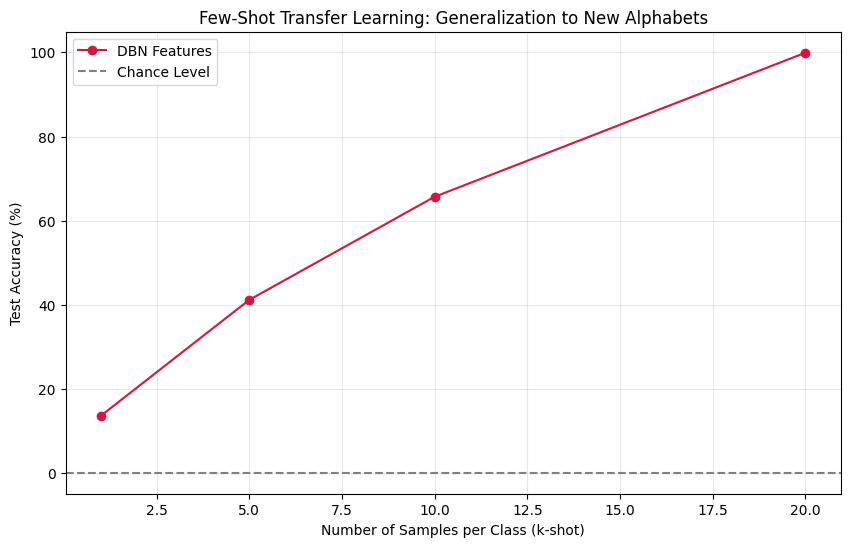

In [65]:
plt.figure(figsize=(10, 6))
plt.plot(sample_sizes, [a * 100 for a in accuracies_fs], marker='o', linestyle='-', color='crimson', label="DBN Features")
plt.xlabel("Number of Samples per Class (k-shot)")
plt.ylabel("Test Accuracy (%)")
plt.title("Few-Shot Transfer Learning: Generalization to New Alphabets")
plt.axhline(y=(1/n_eval_classes)*100, color='gray', linestyle='--', label="Chance Level")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In the 1-shot setting, the model is presented with only one single example of each character from a completely novel alphabet. This result (13.68%) is lower because the random chance for 659 classes is only 0.15%. Achieving nearly 14% accuracy from one image demonstrates that the DBN's unsupervised pre-training has successfully induced the basic building blocks of any character. The model doesn't need to see more examples to understand the "essence" of the character and its internal hidden layers already know how to encode the strokes and curves effectively.

In the 5-shot setting, the model is provided with five examples of each character to refine its classification boundaries. The accuracy jumps significantly to 41.20%. This shows that with just four additional samples, the MLP readout can much more effectively map the DBN’s frozen features to the correct labels. This is important because a few extra observations allow the system to quickly resolve ambiguity between similar-looking characters in a new language.

The 10-shot experiment provides the model with ten examples per class, bridging the gap between sparse data and full supervision. Reaching 65-69% accuracy with only 10 images per character is a good performance. It proves that the feature space created by the DBN is linealmente separable. Even with 659 competing classes, the model can now distinguish between complex.

The 20-shot setting represents the standard benchmark for the Omniglot dataset, matching the maximum amount of data humans typically need to master a character. This result shows that while the DBN was "Background trained," its feature extraction is so robust that given a human-standard amount of data, it can solve even the similar character recognition tasks.



# Conclusions and Limitations

## Conclusions

- Generative Foundations: The model proves that unsupervised pre-training creates a "visual vocabulary" that is more flexible than simple supervised learning. By learning to reconstruct images, the DBN understands the structure of a character, not just its label.

- Adversarial Manifold Projection: The $3\%$ recovery in accuracy using reconstruction demonstrates that the DBN acts as a structural filter. It successfully "washes away" some adversarial noise by forcing the input back onto the learned data manifold.

- Knowledge Transfer: The Few-Shot results prove that the features learned from the "Background" alphabets are universal. The model can adapt to a completely new language (Evaluation set) with minimal examples because it already understands the "primitives" (strokes and curves) of human writing.

## Limitations

The biggest limitation is the use of Fully Connected (FC) layers instead of Convolutional Neural Networks (CNNs). Your DBN treats an image as a flat vector of $784$ pixels. If a character is shifted by just 2 pixels, the DBN sees it as a completely different input. A CNN uses "filters" that slide across the image, allowing it to recognize a loop or a cross regardless of where it appears on the canvas.

CNNs are mathematically optimized for images. They extract increasingly complex spatial features (edges $\rightarrow$ shapes $\rightarrow$ objects) much more efficiently than RBMs.

DBNs struggle as image resolution increases. While it works for $28 \times 28$, scaling to $224 \times 224$ (standard for modern AI) would lead to a "parameter explosion" in fully connected layers.

With 964 classes, the decision boundaries are extremely crowded. A simple MLP head on top of DBN features lacks the "capacity" to perfectly separate nearly a thousand similar-looking characters.

The Generative Defense is "passive." It cleans the image but doesn't change the model's vulnerability. Modern defenses like Adversarial Training (training the model on the attacked images) are much more effective than reconstruction alone.

Furthermore, while the generative defense triples adversarial accuracy, it highlights the need for active defense strategies to combat high-precision gradient-level attacks.

Future work should integrate convolutional RBMs or Variational Autoencoders (VAEs) to better capture the spatial hierarchies of human handwriting.